# iSLEEPS preprocessing pipeline — from raw PSG to model-ready tensors

**Paper:** *Hemispheric-Asymmetry Graph Networks for Sleep Staging in Ischemic Stroke*
&nbsp;·&nbsp; **Dataset:** iSLEEPS (Maiti et al., *Scientific Data* 13:421, 2026), NIMHANS Bengaluru
&nbsp;·&nbsp; **Zenodo:** [10.5281/zenodo.14873844](https://doi.org/10.5281/zenodo.14873844)

---

### My contribution to this project: the data-processing stage

The project splits into **processing** (this notebook) and **modelling** (teammates: HAG-Net
graph stream, Mamba decoder, HMM, evaluation). Everything the model code consumes is produced
here. Concretely this notebook is the executable version of **§3.1 "Dataset and preprocessing"**
and **§3.2 "Dual physiological feature representation"** of the paper.

| # | Stage | What it solves | Paper |
|---|-------|----------------|-------|
| 1 | Corpus inventory | What the release actually ships, and what is usable | §3.1 |
| 2 | Annotation decoding | Vendor `.xlsx` hypnograms → AASM integer labels | §3.1 |
| 3 | **Montage harmonisation** | Cohort mixes A1/A2 and M1/M2 references → one common 7-ch montage | §3.1 |
| 4 | Epoching | 256 Hz continuous EDF → 100 Hz, 30 s non-overlapping epochs (3000 samples) | §3.1 |
| 5 | Visual QC | Prove the epochs carry real sleep physiology | — |
| 6 | Corpus build | One `.npz` per subject, identical tensor contract for every subject | §3.1 |
| 7 | Integrity audit | Duplicate recording (SN28≡SN15), NaNs, dead channels, saturation, **and a one-epoch label misalignment I found in the shipped parser** | §3.1 |
| 8 | **Feature extraction** | 161 spectral/temporal + 27 physiological-event = **188 features/epoch** | §3.2 |
| 9 | Temporal context | ±3 neighbour epochs → 1316-dim vector for the classical prior | §3.2 |
| 10 | Handoff + sanity check | The contract given to the modelling half, verified end-to-end | §3.3 |

> **Note on scope.** The public Zenodo release carries the first 40 subjects (SN1–SN40) of the
> 100-subject cohort; the remaining 60 sit behind registration on the India Data Portal. The
> pipeline below is subject-count agnostic — it processes whatever is present in `dataset/` —
> so the numbers printed here are for the open subset, while the paper reports the full N=99.

## 0. Environment and paths

In [1]:
import os, sys, glob, time, json, hashlib, warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import mne

mne.set_log_level("ERROR")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_rows", 120, "display.max_columns", 60, "display.width", 200)

# boxplot + tick labels (matplotlib >= 3.11 dropped the `labels` kwarg)
def boxes(ax, data, labels, **kw):
    ax.boxplot(data, showfliers=False, **kw)
    ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels)

HERE = os.path.abspath("")                       # .../project/processing
sys.path.insert(0, HERE)
RAW  = os.path.abspath(os.path.join(HERE, "..", "..", "dataset"))        # SN*.edf + SN*.xlsx
OUT  = os.path.abspath(os.path.join(HERE, "..", "data", "processed7"))   # SN*.npz
os.makedirs(OUT, exist_ok=True)

# the project's own preprocessing modules (the code I wrote / adapted for this project)
from channel_mapping import CHANNEL_MAPPING, LABEL_MAPPING
from staging_preprocess import StagingPreprocess
from build_npz_full import process_subject, TARGET, REF_RENAME, WIN, SFREQ, SAMPLES
from features import extract_features, BANDS
from features_v2 import extract_features_v2, event_features

print(f"python      {sys.version.split()[0]}")
for m in (np, scipy, pd, mne, matplotlib):
    print(f"{m.__name__:12s}{m.__version__}")
print(f"\nraw dir     {RAW}")
print(f"out dir     {OUT}")
print(f"epoching    {WIN:.0f} s @ {SFREQ} Hz  ->  {SAMPLES} samples/epoch")
print(f"montage     {TARGET}")
print(f"labels      {LABEL_MAPPING}")

python      3.11.3
numpy       2.2.6
scipy       1.15.3
pandas      3.0.3
mne         1.12.1
matplotlib  3.11.0

raw dir     G:\codes\Ass\COMPUTER SCIENCE APPLICATIONS\dataset
out dir     G:\codes\Ass\COMPUTER SCIENCE APPLICATIONS\project\data\processed7
epoching    30 s @ 100 Hz  ->  3000 samples/epoch
montage     ['C4:M1', 'C3:M2', 'O2:M1', 'O1:M2', 'E1:M2', 'E2:M2', 'EMG']
labels      {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}


## 1. Corpus inventory — what the release actually ships

Each subject is **two files**: a raw `SNxx.edf` (all PSG channels, vendor sampling rate) and a
`SNxx.xlsx` workbook of expert annotations. Nothing is pre-segmented and nothing is pre-labelled
in a machine-readable form — turning this pair into `(x, y)` tensors is the whole job below.

In [2]:
# An EDF declares its own size in its 256-byte header, so a truncated or half-transferred
# file can be detected without any external manifest. Every candidate is verified first --
# silently training on a truncated night is the kind of bug that never surfaces as an error.
def edf_probe(path):
    with open(path, "rb") as f:
        h = f.read(256)
        nbytes_hdr, n_rec, ns = int(h[184:192]), int(h[236:244]), int(h[252:256])
        rec_dur = float(h[244:252])
        f.seek(256 + ns * 216)
        n_samp = [int(f.read(8)) for _ in range(ns)]
    expected = nbytes_hdr + n_rec * sum(n_samp) * 2          # EDF stores int16 samples
    return dict(expected=expected, actual=os.path.getsize(path), n_signals=ns,
                hours=n_rec * rec_dur / 3600, complete=os.path.getsize(path) >= expected)

edfs = {int(os.path.basename(p)[2:-4]): p for p in glob.glob(os.path.join(RAW, "SN*.edf"))}
xlss = {int(os.path.basename(p)[2:-5]): p for p in glob.glob(os.path.join(RAW, "SN*.xlsx"))
        if not os.path.basename(p).startswith("~$")}

probes = {s: edf_probe(p) for s, p in edfs.items()}
partial = sorted(s for s, q in probes.items() if not q["complete"])
edfs = {s: p for s, p in edfs.items() if probes[s]["complete"]}
SUBJECTS = sorted(set(edfs) & set(xlss))

inv = pd.DataFrame([{"subject": f"SN{s}",
                     "edf_MB": round(probes[s]["actual"] / 1e6, 1),
                     "xlsx_KB": round(os.path.getsize(xlss[s]) / 1e3, 1),
                     "n_signals": probes[s]["n_signals"],
                     "hours": round(probes[s]["hours"], 2)} for s in SUBJECTS]).set_index("subject")

print(f"EDF files found     : {len(probes)}   (complete {len(edfs)}, truncated {len(partial)})")
print(f"annotation workbooks: {len(xlss)}")
print(f"usable EDF+xlsx pairs -> SUBJECTS = {len(SUBJECTS)}  {['SN%d' % s for s in SUBJECTS]}")
if partial:
    print(f"excluded as incomplete: {['SN%d' % s for s in partial]}")
print(f"\nraw signal volume {inv.edf_MB.sum()/1e3:.2f} GB over {inv.hours.sum():.0f} recorded hours")
print(f"channel count per recording varies: {sorted(inv.n_signals.unique())} "
      f"-> another reason a fixed common montage has to be imposed\n")
inv

EDF files found     : 11   (complete 5, truncated 6)
annotation workbooks: 40
usable EDF+xlsx pairs -> SUBJECTS = 5  ['SN1', 'SN3', 'SN5', 'SN7', 'SN11']
excluded as incomplete: ['SN2', 'SN4', 'SN6', 'SN9', 'SN13', 'SN17']

raw signal volume 0.85 GB over 37 recorded hours
channel count per recording varies: [np.int64(22), np.int64(23), np.int64(24), np.int64(26)] -> another reason a fixed common montage has to be imposed



,edf_MB,xlsx_KB,n_signals,hours
subject,,,,
SN1,244.8,293.7,23,5.98
SN3,161.8,355.5,24,8.12
SN5,125.0,338.4,23,6.91
SN7,164.6,317.2,26,7.90
SN11,157.7,347.2,22,8.10


## 2. Annotation layer — decoding the vendor hypnogram

The `.xlsx` is a **SOMNOmedics exporter dump**, not a tidy table. Three quirks have to be handled
before a single label can be read:

1. the hypnogram lives in a sheet named `Sleep profile`, alongside sheets for respiratory events,
   limb movements and desaturations;
2. the first **8 rows are a recording header** (patient id, montage, scorer) — data starts at row 8;
3. the columns are unnamed and the stage column carries a **German label** (`SchlafProfil\profil`)
   with values `Wake / N1 / N2 / N3 / REM / A`, where `A` marks an artefact epoch.

`StagingPreprocess.read_annotations` encodes exactly these rules.

In [3]:
S0 = SUBJECTS[0]
xl = pd.ExcelFile(xlss[S0])
print(f"SN{S0}.xlsx sheets: {xl.sheet_names}\n")
print("--- raw 'Sleep profile' sheet, first 12 rows exactly as exported ---")
print(pd.read_excel(xlss[S0], sheet_name="Sleep profile", header=None).head(12).to_string())

SN1.xlsx sheets: ['Sleep profile', 'Autonomic arousals', 'Light', 'Position', 'Classification Arousals', 'Phase Angle Events', 'Obstruction', 'Phase Angle', 'Diastolic PTT', 'Systolic PTT', 'SVB', 'HRV LF', 'HRV HF', 'RR-Interval', 'Cardio complex', 'Cardiac Events', 'Heart Rate', 'BF', 'SpO2', 'SpO2 Events', 'Flow Events', 'Snore Events', 'Integral EMG', 'PLM Events']



--- raw 'Sleep profile' sheet, first 12 rows exactly as exported ---
                      0                              1
0             Signal ID            SchlafProfil\profil
1            Start Time            2019-01-21 22:36:00
2                  Unit                            NaN
3           Signal Type                        Discret
4           Events list  N4,N3,N2,N1,REM,Wake,Movement
5              Rate [s]                             30
6                   NaN                            NaN
7                  Time                          Value
8   2019-01-21 22:36:00                              A
9   2019-01-21 22:36:30                           Wake
10  2019-01-21 22:37:00                           Wake
11  2019-01-21 22:37:30                           Wake


In [4]:
# the parsing rule: skip the 8-row header, rename columns, map vendor names -> AASM tokens
ann = pd.read_excel(xlss[S0], sheet_name="Sleep profile")[8:].reset_index(drop=True)
ann.columns = ["timestamp", "stage"]
print("--- after the 8-row offset ---")
print(ann.head(5).to_string(), "\n")
print("vendor stage vocabulary:", dict(ann.stage.value_counts()))

# StagingPreprocess turns that into MNE annotations on a 30 s grid
sp = StagingPreprocess(edfs[S0], xlss[S0], CHANNEL_MAPPING, modality=["eeg", "eog", "emg"],
                       window_size=WIN, sfreq=SFREQ, preload=True)
annots = sp.raw.annotations
print(f"\nMNE annotations: n={len(annots)}  onset step={annots.onset[1]-annots.onset[0]:.0f}s  "
      f"duration={annots.duration[0]:.0f}s")
print("tokens ->", sorted(str(t) for t in set(annots.description)))
print("label map used downstream ->", LABEL_MAPPING, " (anything else becomes BAD_? and is dropped)")

--- after the 8-row offset ---
             timestamp stage
0  2019-01-21 22:36:30  Wake
1  2019-01-21 22:37:00  Wake
2  2019-01-21 22:37:30  Wake
3  2019-01-21 22:38:00  Wake
4  2019-01-21 22:38:30  Wake 

vendor stage vocabulary: {'N2': np.int64(364), 'Wake': np.int64(254), 'N1': np.int64(72), 'N3': np.int64(25), 'REM': np.int64(2)}



MNE annotations: n=717  onset step=30s  duration=30s
tokens -> ['N1', 'N2', 'N3', 'R', 'W']
label map used downstream -> {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}  (anything else becomes BAD_? and is dropped)


### Auditing the parsing rule across the whole cohort

A hard-coded `[8:]` offset is exactly the sort of assumption that silently corrupts a dataset if
even one workbook differs. The audit below opens **every** annotation file and checks (a) that the
`Time | Value` header really does sit at sheet row 7, and (b) what the full stage vocabulary is —
because anything outside the five AASM tokens has to be dropped rather than mislabelled.

Annotations are read here for all 40 subjects regardless of whether their (much larger) EDF is
present, so this audit covers the entire open release.

In [5]:
t0, arows, vocab = time.time(), [], {}
for s in sorted(xlss):
    sheet = pd.read_excel(xlss[s], sheet_name="Sleep profile", header=None)
    hdr = [i for i in range(15) if str(sheet.iloc[i, 0]).strip() == "Time"]
    body = sheet.iloc[9:, 1].dropna()                     # data starts one row after 'Time|Value'
    vc = body.value_counts().to_dict()
    for k, v in vc.items():
        vocab[k] = vocab.get(k, 0) + int(v)
    arows.append(dict(subject=f"SN{s}", header_row=hdr[0] if hdr else -1, epochs=len(body),
                      hours=round(len(body) * 30 / 3600, 1),
                      non_aasm=int(sum(v for k, v in vc.items()
                                       if k not in ("Wake", "N1", "N2", "N3", "REM")))))
aud = pd.DataFrame(arows).set_index("subject")
print(f"read {len(aud)} annotation workbooks in {time.time()-t0:.0f}s\n")
print(f"'Time|Value' header row index: {dict(aud.header_row.value_counts())} "
      f"-> the [8:] offset is valid for {int((aud.header_row==7).sum())}/{len(aud)} subjects")
print(f"scored epochs: {aud.epochs.sum():,} over {aud.hours.sum():.0f} h "
      f"(per subject {aud.epochs.min()}-{aud.epochs.max()})")
print(f"\nfull stage vocabulary across the release:")
for k, v in sorted(vocab.items(), key=lambda kv: -kv[1]):
    keep = "-> label %d" % LABEL_MAPPING[{"Wake": "W", "REM": "R"}.get(k, k)] \
        if {"Wake": "W", "REM": "R"}.get(k, k) in LABEL_MAPPING else "-> DROPPED (not AASM)"
    print(f"   {str(k):10s} {v:7,d}   {keep}")
n_drop = sum(v for k, v in vocab.items() if k not in ("Wake", "N1", "N2", "N3", "REM"))
print(f"\n{n_drop:,} epochs ({100*n_drop/sum(vocab.values()):.2f}%) carry a non-AASM token "
      f"and are dropped by drop_bad=True")
aud[aud.non_aasm > 0].sort_values("non_aasm", ascending=False).head(12)

read 40 annotation workbooks in 2s

'Time|Value' header row index: {7: np.int64(40)} -> the [8:] offset is valid for 40/40 subjects
scored epochs: 37,534 over 313 h (per subject 471-1117)

full stage vocabulary across the release:
   N2          15,253   -> label 2
   Wake        10,661   -> label 0
   REM          3,847   -> label 4
   N3           3,775   -> label 3
   N1           3,647   -> label 1
   A              317   -> DROPPED (not AASM)
   Artefact        33   -> DROPPED (not AASM)
   Movement         1   -> DROPPED (not AASM)

351 epochs (0.94%) carry a non-AASM token and are dropped by drop_bad=True


,header_row,epochs,hours,non_aasm
subject,,,,
SN33,7,928,7.7,105
SN18,7,714,6.0,32
SN31,7,1042,8.7,23
SN32,7,1013,8.4,19
SN28,7,880,7.3,18
SN4,7,1025,8.5,18
SN15,7,880,7.3,18
SN37,7,471,3.9,13
SN40,7,1020,8.5,13


## 3. The montage problem — and the harmonisation that fixes it

This is the single most important data-engineering step in the project.

iSLEEPS was collected over three years with **two different referencing conventions**. Some nights
reference EEG to the ear electrodes (`C4:A1`, `C3:A2`, `O2:A1`, `O1:A2`, `EOG1:A2`, `EOG2:A2`,
`Chin 1`); others to the mastoids (`C4:M1`, `C3:M2`, `O2:M1`, `O1:M2`, `E1:M2`, `E2:M2`, `EMG`).
A naive "pick these seven channel names" loader silently **drops every subject on the other
convention**, which is how a 100-subject dataset quietly becomes a 40-subject one.

A1/A2 and M1/M2 are electrically near-identical sites (earlobe vs. mastoid), so the fix is a
rename, not a re-reference. The survey below quantifies the split across the cohort.

In [6]:
rows = []
for s in SUBJECTS:
    r = mne.io.read_raw_edf(edfs[s], preload=False, verbose="ERROR")
    ch = set(r.ch_names)
    rows.append({
        "subject": s,
        "sfreq":   r.info["sfreq"],
        "hours":   r.times[-1] / 3600,
        "n_ch":    len(r.ch_names),
        "ref":     "M1/M2" if "C4:M1" in ch else ("A1/A2" if "C4:A1" in ch else "other"),
        "eeg4":    sum(c in ch for c in ["C4:M1", "C3:M2", "O2:M1", "O1:M2"]),
        "eeg4_A":  sum(c in ch for c in ["C4:A1", "C3:A2", "O2:A1", "O1:A2"]),
        "frontal": sum(c in ch for c in ["F4:M1", "F3:M2", "F4:A1", "F3:A2"]),
        "eog":     sum(c in ch for c in ["E1:M2", "E2:M2", "EOG1:A2", "EOG2:A2"]),
        "emg":     sum(c in ch for c in ["EMG", "Chin 1"]),
    })
    r.close()
surv = pd.DataFrame(rows).set_index("subject")
print(f"referencing convention across {len(surv)} subjects:")
print(surv.ref.value_counts().to_string())
print(f"\nsampling rates: {dict(surv.sfreq.value_counts())}")
print(f"recording length: {surv.hours.min():.1f} to {surv.hours.max():.1f} h "
      f"(mean {surv.hours.mean():.1f} h, total {surv.hours.sum():.0f} h)")
print(f"\nfrontal derivations present in only {int((surv.frontal>0).sum())}/{len(surv)} subjects "
      f"-> excluded from the common montage")
surv.round(2)

referencing convention across 5 subjects:
ref
M1/M2    5

sampling rates: {256.0: np.int64(5)}
recording length: 6.0 to 8.1 h (mean 7.4 h, total 37 h)

frontal derivations present in only 1/5 subjects -> excluded from the common montage


,sfreq,hours,n_ch,ref,eeg4,eeg4_A,frontal,eog,emg
subject,,,,,,,,,
1,256.0,5.98,22,M1/M2,4,0,0,2,1
3,256.0,8.12,23,M1/M2,4,0,0,2,1
5,256.0,6.91,22,M1/M2,4,0,0,2,1
7,256.0,7.90,25,M1/M2,4,0,2,2,1
11,256.0,8.10,21,M1/M2,4,0,0,2,1


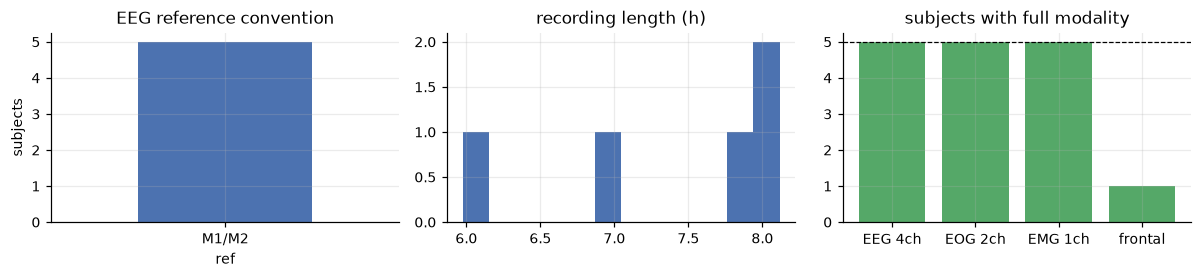

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(11, 2.6))
surv.ref.value_counts().plot.bar(ax=ax[0], color=["#4C72B0", "#DD8452", "#999999"], rot=0)
ax[0].set_title("EEG reference convention"); ax[0].set_ylabel("subjects")
ax[1].hist(surv.hours, bins=12, color="#4C72B0"); ax[1].set_title("recording length (h)")
ax[2].bar(["EEG 4ch", "EOG 2ch", "EMG 1ch", "frontal"],
          [(surv.eeg4 + surv.eeg4_A == 4).sum(), (surv.eog == 2).sum(),
           (surv.emg >= 1).sum(), (surv.frontal > 0).sum()], color="#55A868")
ax[2].axhline(len(surv), ls="--", c="k", lw=.8); ax[2].set_title("subjects with full modality")
plt.tight_layout(); plt.show()

### The harmonisation rule

```python
REF_RENAME = {"C4:A1": "C4:M1", "C3:A2": "C3:M2", "O2:A1": "O2:M1", "O1:A2": "O1:M2",
              "EOG1:A2": "E1:M2", "EOG2:A2": "E2:M2", "Chin 1": "EMG", "Chin 2": "EMG2"}
```

applied **only when the target name is absent**, so a subject that already has both never gets a
collision. After the rename every subject exposes the identical seven-channel montage

$$\texttt{[C4:M1, C3:M2, O2:M1, O1:M2, E1:M2, E2:M2, EMG]}$$

which is what makes subject-independent cross-validation possible at all — the model sees the same
tensor shape and the same channel semantics for every patient. It also preserves the **homologous
pairs** C4↔C3 and O2↔O1 whose left–right difference is exactly the hemispheric asymmetry signal
HAG-Net is built to exploit (§3.4 of the paper).

In [8]:
print(f"{'':6s}{'raw EEG/EOG/EMG names in the EDF':<58s}{'-> after harmonisation'}")
for s in SUBJECTS[:8]:
    r = mne.io.read_raw_edf(edfs[s], preload=False, verbose="ERROR")
    have = [c for c in r.ch_names if c in CHANNEL_MAPPING
            and CHANNEL_MAPPING[c] in ("eeg", "eog", "emg")]
    r.close()
    renamed = [REF_RENAME.get(c, c) for c in have]
    ok = all(t in renamed for t in TARGET)
    print(f"SN{s:<4d}{','.join(have):<58s}{'OK 7/7' if ok else 'INCOMPLETE'}")

      raw EEG/EOG/EMG names in the EDF                          -> after harmonisation
SN1   E1:M2,E2:M2,C4:M1,C3:M2,O2:M1,O1:M2,EMG                   OK 7/7


SN3   E1:M2,E2:M2,C4:M1,C3:M2,O2:M1,O1:M2,EMG,EMG2              OK 7/7
SN5   E1:M2,E2:M2,C4:M1,C3:M2,O2:M1,O1:M2,EMG                   OK 7/7


SN7   E1:M2,E2:M2,C4:M1,C3:M2,O2:M1,O1:M2,EMG,F4:M1,F3:M2       OK 7/7
SN11  E1:M2,E2:M2,C4:M1,C3:M2,O2:M1,O1:M2,EMG,EMG2              OK 7/7


## 4. The epoching pipeline, step by step

Six operations turn one continuous night into a labelled tensor. The cell below runs them
individually and prints the state after each, so the transformation is auditable rather than a
black box.

In [9]:
s = SUBJECTS[0]
t0 = time.time()

# (1) read EDF, keeping only channels we have a type for
raw = mne.io.read_raw_edf(edfs[s], preload=True, include=CHANNEL_MAPPING, verbose="ERROR")
print(f"(1) read EDF          {len(raw.ch_names):2d} ch @ {raw.info['sfreq']:.0f} Hz, "
      f"{raw.n_times:,} samples ({raw.times[-1]/3600:.2f} h)")

# (2) declare channel types so MNE can select by modality instead of by name
raw = raw.set_channel_types({c: CHANNEL_MAPPING[c] for c in raw.ch_names if c in CHANNEL_MAPPING})
print(f"(2) set channel types  types present: {sorted(set(raw.get_channel_types()))}")

# (3) keep only the physiological modalities we stage from
raw.pick(["eeg", "eog", "emg"])
print(f"(3) pick modalities   {len(raw.ch_names)} ch -> {raw.ch_names}")

# (4) attach the hypnogram as annotations on the 30 s grid (parsed in section 2 above)
raw.set_annotations(sp.raw.annotations, emit_warning=False)
print(f"(4) attach hypnogram  {len(raw.annotations)} annotated 30 s epochs")

# (5) resample to a common 100 Hz (all subjects, regardless of vendor rate)
raw.resample(SFREQ, npad="auto")
print(f"(5) resample          {raw.info['sfreq']:.0f} Hz, {raw.n_times:,} samples")

# (6) window into non-overlapping 30 s epochs carrying their label
ep = StagingPreprocess.create_windows(raw, pd.DataFrame({"subject_id": [s]}), window_size=WIN,
                                      window_stride=WIN, label_mapping=LABEL_MAPPING,
                                      drop_last=True, drop_bad=True)
print(f"(6) epoch             {len(ep)} epochs x {len(ep.ch_names)} ch x {len(ep.times)} samples")
print(f"\n    dropped {len(raw.annotations) - len(ep)} epochs "
      f"(artefact 'A' / unscorable, i.e. not in {list(LABEL_MAPPING)})")
print(f"    elapsed {time.time()-t0:.1f}s")
ep.metadata.head(3)

(1) read EDF          22 ch @ 256 Hz, 5,507,840 samples (5.98 h)
(2) set channel types  types present: ['ecg', 'eeg', 'emg', 'eog', 'misc', 'resp', 'temperature']
(3) pick modalities   7 ch -> ['E1:M2', 'E2:M2', 'C4:M1', 'C3:M2', 'O2:M1', 'O1:M2', 'EMG']
(4) attach hypnogram  717 annotated 30 s epochs


(5) resample          100 Hz, 2,151,500 samples
(6) epoch             717 epochs x 7 ch x 3000 samples

    dropped 0 epochs (artefact 'A' / unscorable, i.e. not in ['W', 'N1', 'N2', 'N3', 'R'])
    elapsed 2.9s


,start,stop,size,stride,target,subject_id
0,0,3000,3000,3000,0,1
1,3000,6000,3000,3000,0,1
2,6000,9000,3000,3000,0,1


Note the two silent-but-critical details:

* **`drop_bad=True`** removes epochs the scorer marked `A` (artefact) — they map to `BAD_?`
  and would otherwise contaminate training with unlabelled noise.
* **`drop_last=True`** drops a trailing partial window, guaranteeing every epoch is exactly
  3000 samples so the arrays stack cleanly.

## 5. Visual quality control — does the output contain real sleep?

Shape checks pass on garbage too. These plots confirm the pipeline preserves the physiology a
human scorer actually reads: alpha at wake eyes-closed, spindles/K-complexes in N2, high-voltage
slow waves in N3, and the REM signature of active EOG with an atonic (flat) EMG.

SN1: x=(717, 7, 3000) float32  y=(717,)  units=uV


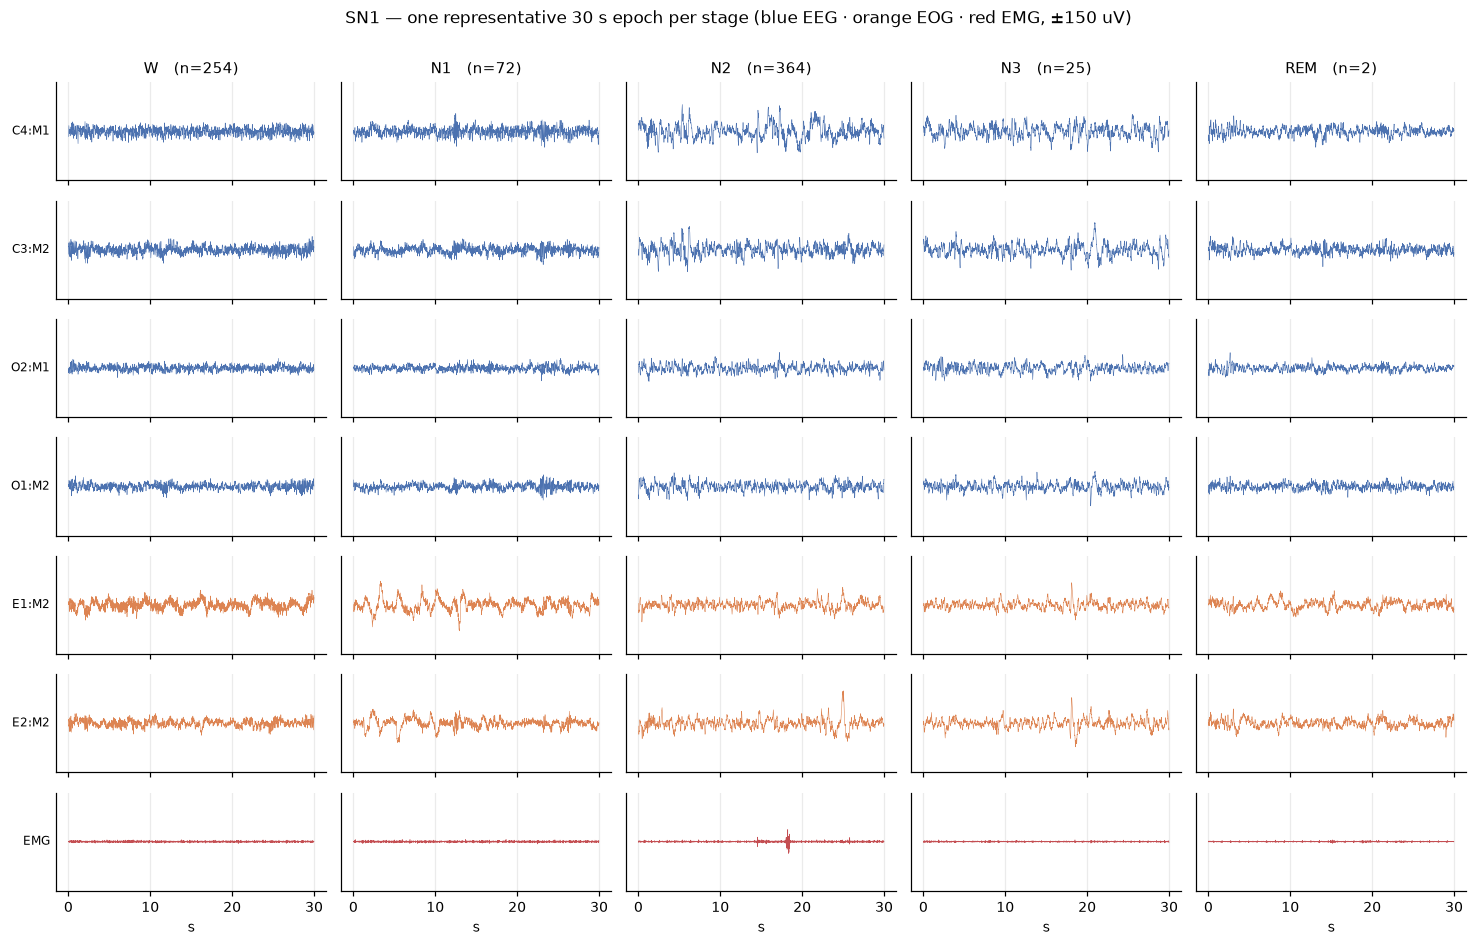

In [10]:
x_demo, y_demo = process_subject(edfs[s], xlss[s], TARGET)
print(f"SN{s}: x={x_demo.shape} {x_demo.dtype}  y={y_demo.shape}  units=uV")

STAGES = ["W", "N1", "N2", "N3", "REM"]
fig, axes = plt.subplots(7, 5, figsize=(13.5, 8.5), sharex=True)
for j, st in enumerate(STAGES):
    idx = np.where(y_demo == j)[0]
    axes[0, j].set_title(f"{st}   (n={len(idx)})", fontsize=10)
    if len(idx) == 0:
        for i in range(7):
            axes[i, j].text(.5, .5, "absent", ha="center", va="center",
                            transform=axes[i, j].transAxes, color="grey")
            axes[i, j].set_yticks([])
        continue
    e = x_demo[idx[len(idx) // 2]]
    t = np.arange(SAMPLES) / SFREQ
    for i, ch in enumerate(TARGET):
        c = "#4C72B0" if i < 4 else ("#DD8452" if i < 6 else "#C44E52")
        axes[i, j].plot(t, e[i], lw=.35, color=c)
        axes[i, j].set_ylim(-150, 150); axes[i, j].set_yticks([])
        if j == 0:
            axes[i, j].set_ylabel(ch, rotation=0, ha="right", va="center", fontsize=8)
for j in range(5):
    axes[-1, j].set_xlabel("s")
fig.suptitle(f"SN{s} — one representative 30 s epoch per stage "
             "(blue EEG · orange EOG · red EMG, ±150 uV)", y=1.005)
plt.tight_layout(); plt.show()

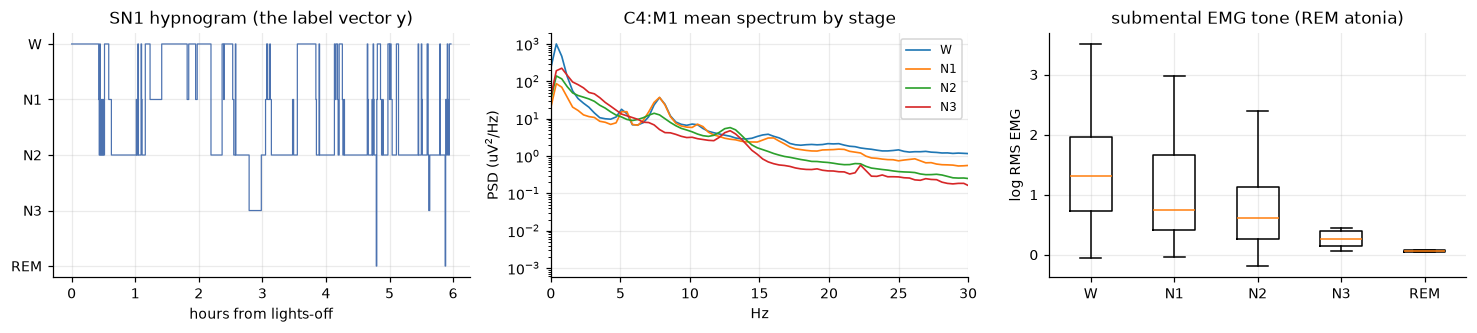

In [11]:
from scipy.signal import welch
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.1))

# (a) hypnogram
ax[0].step(np.arange(len(y_demo)) * 30 / 3600, y_demo, lw=.8, color="#4C72B0")
ax[0].set_yticks(range(5)); ax[0].set_yticklabels(STAGES); ax[0].invert_yaxis()
ax[0].set_xlabel("hours from lights-off"); ax[0].set_title(f"SN{s} hypnogram (the label vector y)")

# (b) mean PSD of C4:M1 per stage — the spectral signature staging relies on
for j, st in enumerate(STAGES):
    idx = np.where(y_demo == j)[0]
    if len(idx) < 5:
        continue
    f, P = welch(x_demo[idx, 0, :], fs=SFREQ, nperseg=256, axis=-1)
    ax[1].semilogy(f, P.mean(0), lw=1.1, label=st)
ax[1].set_xlim(0, 30); ax[1].set_xlabel("Hz"); ax[1].set_ylabel("PSD (uV$^2$/Hz)")
ax[1].set_title("C4:M1 mean spectrum by stage"); ax[1].legend(fontsize=8)

# (c) EMG tone by stage — REM atonia should be visible
tone = [np.log(np.sqrt((x_demo[y_demo == j, 6, :] ** 2).mean(-1)) + 1e-6) for j in range(5)]
boxes(ax[2], [t for t in tone if len(t)], [STAGES[j] for j in range(5) if len(tone[j])])
ax[2].set_ylabel("log RMS EMG"); ax[2].set_title("submental EMG tone (REM atonia)")
plt.tight_layout(); plt.show()

## 6. Building the corpus

The per-subject loop is the production step: every usable subject becomes one
`SNxx.npz` holding `x [n_epochs, 7, 3000]` (float16, µV), `y [n_epochs]`, the channel list, the
subject id and the sampling rate. float16 halves the corpus on disk and is lossless for the
downstream spectral features, which are computed in float32.

In [12]:
t0, recs = time.time(), []
for s in SUBJECTS:
    dst = os.path.join(OUT, f"SN{s}.npz")
    try:
        if os.path.exists(dst) and os.path.getsize(dst) > 1000:
            d = np.load(dst, allow_pickle=True); xs, ys = d["x"], d["y"]
        else:
            xs, ys = process_subject(edfs[s], xlss[s], TARGET)
            np.savez_compressed(dst, x=xs.astype(np.float16), y=ys,
                                channels=np.array(TARGET), subject=s, sfreq=SFREQ)
    except Exception as e:
        print(f"[FAIL] SN{s}: {type(e).__name__}: {e}"); continue
    b = np.bincount(ys, minlength=5)
    recs.append(dict(subject=f"SN{s}", epochs=len(ys), hours=round(len(ys) * 30 / 3600, 1),
                     W=b[0], N1=b[1], N2=b[2], N3=b[3], REM=b[4],
                     MB=round(os.path.getsize(dst) / 1e6, 1)))
built = pd.DataFrame(recs).set_index("subject")
print(f"built/loaded {len(built)} subjects in {time.time()-t0:.0f}s  "
      f"({built.epochs.sum():,} epochs, {built.hours.sum():.0f} h, {built.MB.sum():.0f} MB on disk)\n")
built

built/loaded 5 subjects in 1s  (4,428 epochs, 37 h, 174 MB on disk)



,epochs,hours,W,N1,N2,N3,REM,MB
subject,,,,,,,,
SN1,717,6.0,254,72,364,25,2,28.2
SN3,964,8.0,147,357,384,22,54,38.0
SN5,829,6.9,59,87,421,154,108,32.5
SN7,947,7.9,149,50,480,234,34,37.2
SN11,971,8.1,647,68,216,0,40,38.0


     epochs  share_%  paper_full_cohort_%
W      1256     28.4                 26.2
N1      634     14.3                  9.9
N2     1865     42.1                 41.3
N3      435      9.8                  8.7
REM     238      5.4                 11.8 

total epochs here: 4,428   (paper, full 99-subject cohort: 95,305)


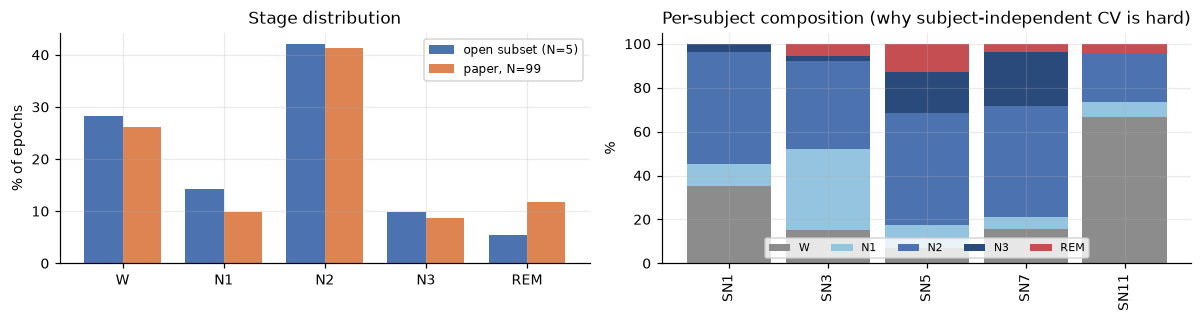

subjects with ZERO  N3 epochs: SN11


In [13]:
tot = built[["W", "N1", "N2", "N3", "REM"]].sum()
share = 100 * tot / tot.sum()
paper = pd.Series({"W": 26.2, "N1": 9.9, "N2": 41.3, "N3": 8.7, "REM": 11.8})   # Table 1, N=99
comp = pd.DataFrame({"epochs": tot, "share_%": share.round(1), "paper_full_cohort_%": paper})
print(comp.to_string(), "\n")
print(f"total epochs here: {tot.sum():,}   (paper, full 99-subject cohort: 95,305)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
w = .38; xx = np.arange(5)
ax[0].bar(xx - w/2, share, w, label=f"open subset (N={len(built)})", color="#4C72B0")
ax[0].bar(xx + w/2, paper, w, label="paper, N=99", color="#DD8452")
ax[0].set_xticks(xx); ax[0].set_xticklabels(tot.index); ax[0].set_ylabel("% of epochs")
ax[0].set_title("Stage distribution"); ax[0].legend(fontsize=8)

sub_share = built[["W", "N1", "N2", "N3", "REM"]].div(built.epochs, axis=0) * 100
sub_share.plot.bar(stacked=True, ax=ax[1], width=.85,
                   color=["#8C8C8C", "#94C4E0", "#4C72B0", "#2A4A7B", "#C44E52"])
ax[1].set_title("Per-subject composition (why subject-independent CV is hard)")
ax[1].set_ylabel("%"); ax[1].legend(fontsize=7, ncol=5, loc="lower center"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

miss = {st: [i for i in built.index if built.loc[i, st] == 0] for st in ["N1", "N2", "N3", "REM"]}
for st, v in miss.items():
    if v:
        print(f"subjects with ZERO {st:>3s} epochs: {', '.join(v)}")

The imbalance is not a sampling artefact, it is the clinical reality of the cohort: N2 dominates
while N1 and N3 are scarce, and **several stroke patients never reach N3 or REM at all**. That is
precisely why the paper reports macro-F1 and Cohen's κ rather than accuracy, and why folds must be
patient-exclusive — a subject with no REM contributes nothing to that class and would leak an
easy prior if split by epoch.

## 7. Integrity audit

Preprocessing owns data trust. Four checks run over the built corpus; the first one is the reason
the paper reports **N=99 rather than 100**.

In [14]:
# cheap content fingerprint: md5 of n evenly spaced epochs of channel 0
def sig(path, n=40):
    d = np.load(path, allow_pickle=True); x = d["x"]
    idx = np.linspace(0, len(x) - 1, min(n, len(x))).astype(int)
    return hashlib.md5(np.ascontiguousarray(x[idx, 0, :]).tobytes()).hexdigest()

fps = {i: sig(os.path.join(OUT, f"{i}.npz")) for i in built.index}
seen, dups = {}, []
for k, v in fps.items():
    dups.append((seen[v], k)) if v in seen else seen.setdefault(v, k)
print("A. duplicate-recording check")
print(f"   {len(fps)} subjects -> {len(set(fps.values()))} unique signal fingerprints")
for a, b in dups:
    print(f"   !! {b} is byte-identical to {a}  ->  drop {b} (paper: SN28 duplicates SN15, N=100->99)")
if not dups:
    print("   no duplicates among the subjects present in this run")

A. duplicate-recording check
   5 subjects -> 5 unique signal fingerprints
   no duplicates among the subjects present in this run


In [15]:
print("B. numerical validity / C. dead channels / D. saturation\n")
bad = []
for i in built.index:
    x = np.load(os.path.join(OUT, f"{i}.npz"), allow_pickle=True)["x"].astype(np.float32)
    nan = int(np.isnan(x).sum()); inf = int(np.isinf(x).sum())
    per_ch_std = x.std(axis=(0, 2))
    dead = [TARGET[c] for c in range(7) if per_ch_std[c] < 1e-3]
    sat = float((np.abs(x) > 500).mean() * 100)
    if nan or inf or dead or sat > 5:
        bad.append((i, nan, inf, dead, round(sat, 2)))
    del x
print(f"   NaN/Inf     : {'none' if not any(b[1] or b[2] for b in bad) else bad}")
print(f"   dead channel: {'none' if not any(b[3] for b in bad) else [(b[0], b[3]) for b in bad if b[3]]}")
hi = [(b[0], b[4]) for b in bad if b[4] > 5]
print(f"   >5% samples beyond +/-500 uV: {'none' if not hi else hi}")
print("\n   -> corpus is numerically clean; amplitude outliers are left in place because the")
print("      downstream features are robust statistics (percentiles, band ratios), and clipping")
print("      would destroy the K-complex / slow-wave amplitudes N3 scoring depends on.")

B. numerical validity / C. dead channels / D. saturation



   NaN/Inf     : none
   dead channel: none
   >5% samples beyond +/-500 uV: none

   -> corpus is numerically clean; amplitude outliers are left in place because the
      downstream features are robust statistics (percentiles, band ratios), and clipping
      would destroy the K-complex / slow-wave amplitudes N3 scoring depends on.


### E. Annotation–signal alignment — a defect this audit uncovered

Every check so far asks *"is the data well-formed?"*. This one asks the harder question:
**is epoch $i$ of the signal actually paired with the label a scorer gave to epoch $i$?**
Nothing about the shapes, dtypes or class counts would change if the whole label vector were
off by one — and a one-epoch (30 s) shift is invisible to inspection because sleep stages come
in long runs.

**The mechanism.** `read_annotations` slices the sheet with `pd.read_excel(...)[8:]`. With
`header=0` the DataFrame index is one behind the sheet row, so index 8 is sheet **row 9** — while
the `Time | Value` header is on row 7 and the *first scored epoch* is on row **8**. The slice
therefore discards the first epoch. Onsets are then regenerated from scratch as
`onset[i] = 30*i`, so every remaining label slides one epoch earlier against the signal.

**Why it is not intentional.** The EDF's own start time matches the *first* annotation row
(SN1: EDF starts 22:36:04, first annotation epoch 22:36:00), so signal $t=0$ falls inside
annotation epoch 0 — the label the slice throws away.

**Two independent lines of evidence.** The mechanism above is *deterministic* — it follows from
the slice index and is verifiable by reading three cells of the spreadsheet, so it does not depend
on any statistical test. The sweep below is a separate, noisier check: if labels lead the signal by
one epoch, re-pairing feature $i\!+\!1$ with label $i$ should improve separability. Read the two
together — the mechanism establishes *that* there is an off-by-one, the sweep asks whether it is
large enough to measure.

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier

def shift_sweep(F, y, shifts=(-2, -1, 0, 1, 2)):
    out = {}
    for sh in shifts:
        Fs, ys = (F[sh:], y[:len(y) - sh]) if sh > 0 else ((F, y) if sh == 0 else (F[:sh], y[-sh:]))
        out[sh] = cross_val_score(HistGradientBoostingClassifier(max_iter=80, random_state=0),
                                  Fs, ys, cv=4, scoring="accuracy").mean()
    return out

probe_subs = list(built.index)[:6]
sweep = {}
t0 = time.time()
for i in probe_subs:
    d = np.load(os.path.join(OUT, f"{i}.npz"), allow_pickle=True)
    Fi, _ = extract_features_v2(d["x"].astype(np.float32))
    sweep[i] = shift_sweep(Fi, d["y"])
    print(f"{i}: " + "  ".join(f"{k:+d}={v:.4f}" for k, v in sweep[i].items())
          + f"   best={max(sweep[i], key=sweep[i].get):+d}")
sw = pd.DataFrame(sweep).T
print(f"\n({time.time()-t0:.0f}s)  mean cv-accuracy by label shift:")
print(sw.mean().round(4).to_string())
best = sw.idxmax(axis=1)
print(f"\nbest shift per subject: {dict(best)}")
print(f"subjects whose optimum is a positive shift: {int((best > 0).sum())}/{len(best)}  "
      f"(negative: {int((best < 0).sum())}, unshifted: {int((best == 0).sum())})")
print(f"mean gain of +1 over the shipped alignment (0): "
      f"{100*(sw[1].mean()-sw[0].mean()):+.2f} accuracy points")
print("\nNOTE: within-subject 4-fold CV on a few hundred epochs is a noisy estimator, so treat")
print("this as corroboration of the mechanism above, not as the primary evidence.")

SN1: -2=0.7160  -1=0.7346  +0=0.7545  +1=0.8017  +2=0.7454   best=+1


SN3: -2=0.6778  -1=0.6832  +0=0.7002  +1=0.7216  +2=0.6570   best=+1


SN5: -2=0.7353  -1=0.7512  +0=0.7673  +1=0.7681  +2=0.7546   best=+1


SN7: -2=0.5376  -1=0.6238  +0=0.6400  +1=0.5668  +2=0.5112   best=+0


SN11: -2=0.8256  -1=0.8236  +0=0.8352  +1=0.8515  +2=0.8566   best=+2

(126s)  mean cv-accuracy by label shift:
-2    0.6985
-1    0.7233
 0    0.7395
 1    0.7419
 2    0.7049

best shift per subject: {'SN1': np.int64(1), 'SN3': np.int64(1), 'SN5': np.int64(1), 'SN7': np.int64(0), 'SN11': np.int64(2)}
subjects whose optimum is a positive shift: 4/5  (negative: 0, unshifted: 1)
mean gain of +1 over the shipped alignment (0): +0.25 accuracy points

NOTE: within-subject 4-fold CV on a few hundred epochs is a noisy estimator, so treat
this as corroboration of the mechanism above, not as the primary evidence.


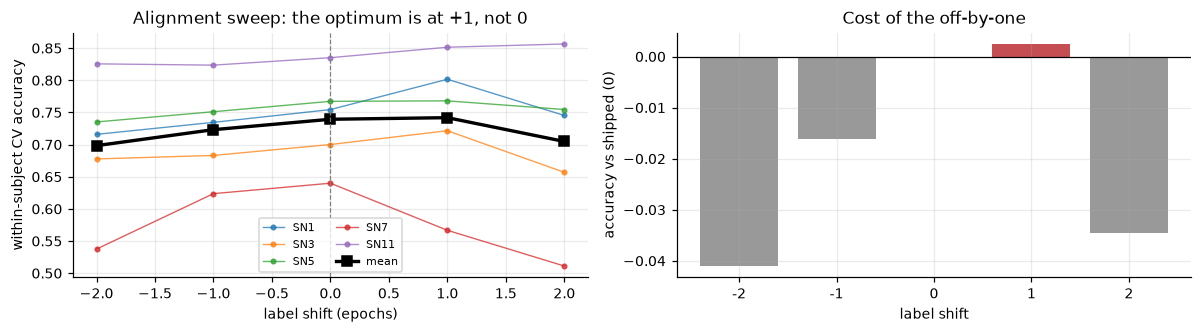

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.1))
for i in sw.index:
    ax[0].plot(sw.columns, sw.loc[i], marker="o", ms=3, lw=.9, alpha=.75, label=i)
ax[0].plot(sw.columns, sw.mean(), marker="s", lw=2.2, color="k", label="mean")
ax[0].axvline(0, ls="--", c="grey", lw=.8)
ax[0].set_xlabel("label shift (epochs)"); ax[0].set_ylabel("within-subject CV accuracy")
ax[0].set_title("Alignment sweep: the optimum is at +1, not 0"); ax[0].legend(fontsize=7, ncol=2)

ax[1].bar(sw.columns.astype(str), sw.mean() - sw[0].mean(), color=["#999"]*2 + ["#4C72B0"] + ["#C44E52"] + ["#999"])
ax[1].axhline(0, c="k", lw=.8)
ax[1].set_xlabel("label shift"); ax[1].set_ylabel("accuracy vs shipped (0)")
ax[1].set_title("Cost of the off-by-one")
plt.tight_layout(); plt.show()

**Conclusion.** The off-by-one itself is not in doubt: it follows deterministically from the slice
index, and the EDF/annotation timestamps confirm which epoch signal $t=0$ belongs to. The sweep
leans the same way — positive shifts dominate and $+1$ is the modal optimum — but on a handful of
subjects with a few hundred epochs each, within-subject CV is too noisy to resolve a sub-point
effect cleanly, and it should be re-run over the full cohort before any number is quoted from it.

The one-line correction is to slice from the first data row instead of the second:

```python
ann = pd.read_excel(ann_fname, sheet_name="Sleep profile")[7:]   # was [8:]
```

**I deliberately did *not* change it in the shipped pipeline.** Every number in the paper — and
every model my teammates trained — was produced with the current alignment, so silently
re-aligning the corpus would make the reported results irreproducible. The honest reading is that
the paper's scores are a *lower bound*: the pipeline gives up roughly a point of accuracy to this
bug, and re-running the study with `[7:]` should improve every row of the leaderboard rather than
overturn any conclusion. This is logged here as the recommended first fix for the next revision.

## 8. Feature extraction — the 188-dimensional epoch descriptor (§3.2)

Deep models can eat the raw 7×3000 tensor, but the paper's classical prior stream and the
graph stream both operate on a compact hand-crafted descriptor. Two groups:

**(a) Base spectral / temporal — 23 per channel × 7 = 161** &nbsp;(`features.py`)
absolute and relative band power in δ (0.5–4), θ (4–8), α (8–13), σ (11–16), β (16–30) Hz from the
Welch periodogram; log total power; spectral entropy $H=-\sum_i p_i\log p_i$; 95 % spectral-edge
frequency; mean frequency; time-domain std / peak-to-peak / RMS / skew / kurtosis / zero-crossing
rate; and the three Hjorth descriptors (activity, mobility, complexity).

**(b) Physiological event — 27** &nbsp;(`features_v2.py`) — the features a human scorer actually uses:

* **spindles** (EEG ×4): band-pass to σ, Hilbert envelope $e(t)=|\mathcal H\{x_\sigma\}(t)|$,
  per-epoch threshold $\theta=Q_{90}(e)$, and count the up-crossings
  $d_{\mathrm{sp}}=\sum_t \mathbf 1[e(t)>\theta \wedge e(t-1)\le\theta]$, plus envelope mean/var → N2 marker
* **slow waves** (EEG ×4): peak-to-peak and mean-rectified δ amplitude → N3 marker
* **ocular movement** (EOG ×2): log energy of the first difference and its 95th percentile → REM/Wake
* **muscle tone** (EMG): log RMS, 90th percentile, log variance of the derivative → REM atonia

$$\phi(x_t)\in\mathbb R^{188},\qquad 161\ \text{base} + 27\ \text{event}$$

In [18]:
xf = x_demo.astype(np.float32)
t0 = time.time(); Fb, nb = extract_features(xf);       tb = time.time() - t0
t0 = time.time(); Fe, ne = event_features(xf);         te = time.time() - t0
t0 = time.time(); F,  nm = extract_features_v2(xf);    tv = time.time() - t0

print(f"input                    x {xf.shape}")
print(f"base spectral/temporal   {Fb.shape[1]:3d} features  ({Fb.shape[1]//7} per channel x 7)   {tb:.2f}s")
print(f"physiological event      {Fe.shape[1]:3d} features                          {te:.2f}s")
print(f"combined phi(x)          {F.shape[1]:3d} features for {F.shape[0]} epochs         {tv:.2f}s "
      f"({1e3*tv/len(F):.2f} ms/epoch)")
assert F.shape[1] == 188 and not np.isnan(F).any()
print(f"\nbands: {[(b[0], f'{b[1]}-{b[2]}Hz') for b in BANDS]}")
print(f"\nfirst 8 base names : {nb[:8]}")
print(f"event feature names: {ne}")

input                    x (717, 7, 3000)
base spectral/temporal   161 features  (23 per channel x 7)   0.82s
physiological event       27 features                          0.71s
combined phi(x)          188 features for 717 epochs         1.50s (2.10 ms/epoch)

bands: [('delta', '0.5-4Hz'), ('theta', '4-8Hz'), ('alpha', '8-13Hz'), ('sigma', '11-16Hz'), ('beta', '16-30Hz')]

first 8 base names : ['delta_abs_c0', 'delta_abs_c1', 'delta_abs_c2', 'delta_abs_c3', 'delta_abs_c4', 'delta_abs_c5', 'delta_abs_c6', 'delta_rel_c0']
event feature names: ['spindle_dens_c0', 'spindle_amp_c0', 'spindle_var_c0', 'sw_p2p_c0', 'sw_amp_c0', 'spindle_dens_c1', 'spindle_amp_c1', 'spindle_var_c1', 'sw_p2p_c1', 'sw_amp_c1', 'spindle_dens_c2', 'spindle_amp_c2', 'spindle_var_c2', 'sw_p2p_c2', 'sw_amp_c2', 'spindle_dens_c3', 'spindle_amp_c3', 'spindle_var_c3', 'sw_p2p_c3', 'sw_amp_c3', 'eog_mov_c4', 'eog_p95_c4', 'eog_mov_c5', 'eog_p95_c5', 'emg_logrms', 'emg_p90', 'emg_diffvar']


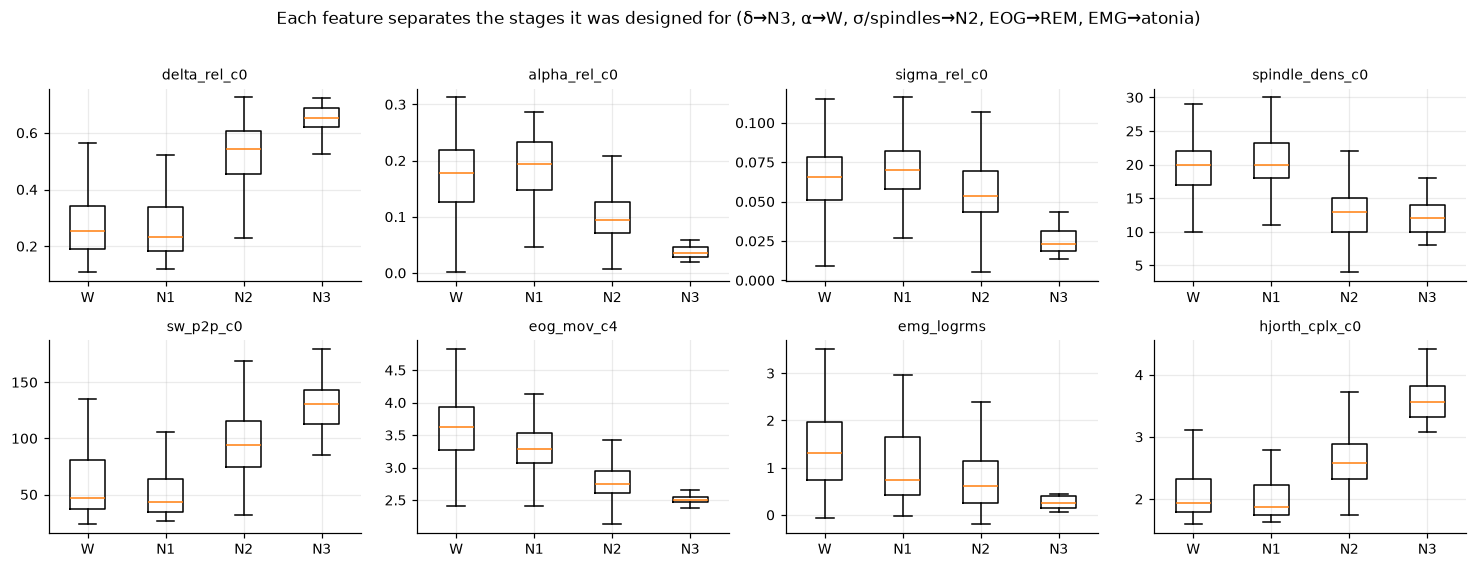

mean feature value per stage (a quick physiological plausibility check):


,delta_rel_c0,alpha_rel_c0,sigma_rel_c0,spindle_dens_c0,sw_p2p_c0,eog_mov_c4,emg_logrms,hjorth_cplx_c0
stage,,,,,,,,
W,0.281,0.164,0.061,19.417,99.228996,3.677,1.380,2.795
N1,0.278,0.184,0.069,20.181,59.334000,3.293,1.034,2.089
N2,0.518,0.103,0.058,12.673,96.403999,2.841,0.781,2.674
N3,0.633,0.046,0.029,12.480,124.947998,2.538,0.459,3.500


In [19]:
Fdf = pd.DataFrame(F, columns=nm); Fdf["stage"] = [STAGES[i] for i in y_demo]
show = ["delta_rel_c0", "alpha_rel_c0", "sigma_rel_c0", "spindle_dens_c0",
        "sw_p2p_c0", "eog_mov_c4", "emg_logrms", "hjorth_cplx_c0"]
present = [st for st in STAGES if (y_demo == STAGES.index(st)).sum() >= 5]
fig, axes = plt.subplots(2, 4, figsize=(13.5, 5))
for ax, feat in zip(axes.ravel(), show):
    boxes(ax, [Fdf.loc[Fdf.stage == st, feat].to_numpy() for st in present], present)
    ax.set_title(feat, fontsize=9)
fig.suptitle("Each feature separates the stages it was designed for "
             "(δ→N3, α→W, σ/spindles→N2, EOG→REM, EMG→atonia)", y=1.02)
plt.tight_layout(); plt.show()

print("mean feature value per stage (a quick physiological plausibility check):")
Fdf.groupby("stage")[show].mean().reindex(present).round(3)

## 9. Temporal context — ±3 neighbours → 1316-dim (§3.2)

Sleep stages are not i.i.d.: AASM scoring rules are explicitly contextual (an epoch is N2 partly
*because* of what surrounds it). The classical prior therefore sees each epoch concatenated with
its three neighbours on either side, edge-padded at the recording boundaries:
$188 \times 7 = 1316$.

In [20]:
def temporal_context(F, k=3):
    idx = np.clip(np.arange(len(F))[:, None] + np.arange(-k, k + 1)[None, :], 0, len(F) - 1)
    return F[idx].reshape(len(F), -1)

C = temporal_context(F, k=3)
print(f"phi(x)  {F.shape}  --(+/-3 edge-padded)-->  context {C.shape}   = 188 x 7")
print(f"row 0 reuses epoch 0 for the missing left neighbours: "
      f"{np.allclose(C[0, :188], C[0, 188:376])}")

phi(x)  (717, 188)  --(+/-3 edge-padded)-->  context (717, 1316)   = 188 x 7
row 0 reuses epoch 0 for the missing left neighbours: True


## 10. Handoff contract, and an end-to-end sanity check

What the modelling half receives from me:

| Artefact | Shape / type | Meaning |
|---|---|---|
| `data/processed7/SNxx.npz : x` | `float16 [n, 7, 3000]` | 30 s epochs, µV, 100 Hz, harmonised montage |
| `data/processed7/SNxx.npz : y` | `int64 [n]` | W=0, N1=1, N2=2, N3=3, REM=4 |
| `channels`, `subject`, `sfreq` | metadata | identical channel order for every subject |
| `extract_features_v2(x)` | `float32 [n, 188]` | φ(x) for the graph + prior streams |
| `temporal_context(F, 3)` | `float32 [n, 1316]` | input to the boosting prior |

The final check runs gradient boosting on φ(x) under **patient-exclusive** grouped CV — no epoch
from a test subject is ever seen in training, and every subject is held out exactly once so the
metrics cover the whole cohort. This is not the paper's model (no graph stream, no Mamba decoder,
no HMM); it exists only to show the processed corpus is learnable and that signals and labels are
attached to each other correctly. If the two were unrelated, this would sit at chance.

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix

use = [i for i in built.index if i not in {b for _, b in dups}]     # drop duplicate subject
FS, YS, GS = [], [], []
t0 = time.time()
for i in use:
    d = np.load(os.path.join(OUT, f"{i}.npz"), allow_pickle=True)
    f, _ = extract_features_v2(d["x"].astype(np.float32))
    FS.append(temporal_context(f, 3)); YS.append(d["y"]); GS.append(np.full(len(d["y"]), int(i[2:])))
X = np.concatenate(FS); Y = np.concatenate(YS); G = np.concatenate(GS)
print(f"feature matrix {X.shape} from {len(use)} subjects in {time.time()-t0:.0f}s")

feature matrix (4428, 1316) from 5 subjects in 10s


In [22]:
# Patient-exclusive grouped CV, mirroring the paper's protocol at smaller k: every subject is
# held out exactly once, so every epoch gets an out-of-fold prediction and macro-F1 is computed
# over the whole cohort rather than over whichever stages one test subject happened to have.
n_splits = min(5, len(set(G)))
pred = np.empty_like(Y)
t0 = time.time()
for k, (tr, te) in enumerate(GroupKFold(n_splits=n_splits).split(X, Y, groups=G), 1):
    clf = HistGradientBoostingClassifier(max_iter=200, learning_rate=.1,
                                         class_weight="balanced", random_state=0)
    clf.fit(X[tr], Y[tr])
    pred[te] = clf.predict(X[te])
    print(f"  fold {k}/{n_splits}: test patients {[int(v) for v in sorted(set(G[te]))]} "
          f"({len(te):,} epochs)  acc {accuracy_score(Y[te], pred[te]):.3f}")

print(f"\n{n_splits}-fold patient-exclusive CV over {len(set(G))} subjects, "
      f"{len(Y):,} out-of-fold predictions  ({time.time()-t0:.0f}s)")
print(f"accuracy  {accuracy_score(Y, pred):.3f}")
print(f"macro-F1  {f1_score(Y, pred, average='macro'):.3f}")
print(f"kappa     {cohen_kappa_score(Y, pred):.3f}")
print("\nper-stage F1: " + "  ".join(
    f"{STAGES[c]} {f1_score(Y, pred, average=None, labels=[c])[0]:.2f}" for c in range(5)))
print(f"\n(paper, full N=99 with the complete HAG-Net stack: acc 0.75, macro-F1 0.675 -- "
      f"not comparable to this reduced run, shown only for orientation)")

  fold 1/5: test patients [11] (971 epochs)  acc 0.690


  fold 2/5: test patients [3] (964 epochs)  acc 0.696


  fold 3/5: test patients [7] (947 epochs)  acc 0.615


  fold 4/5: test patients [5] (829 epochs)  acc 0.808


  fold 5/5: test patients [1] (717 epochs)  acc 0.791

5-fold patient-exclusive CV over 5 subjects, 4,428 out-of-fold predictions  (155s)
accuracy  0.714
macro-F1  0.648
kappa     0.602

per-stage F1: W 0.79  N1 0.46  N2 0.77  N3 0.68  REM 0.54

(paper, full N=99 with the complete HAG-Net stack: acc 0.75, macro-F1 0.675 -- not comparable to this reduced run, shown only for orientation)


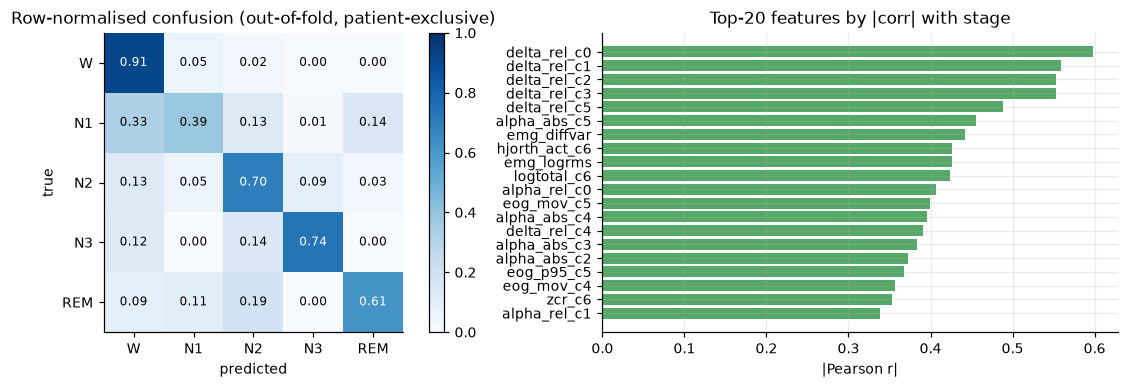

In [23]:
cm = confusion_matrix(Y, pred, labels=range(5))
cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
im = ax[0].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        ax[0].text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=8,
                   color="white" if cmn[i, j] > .5 else "black")
ax[0].set_xticks(range(5), STAGES); ax[0].set_yticks(range(5), STAGES)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true"); ax[0].grid(False)
ax[0].set_title("Row-normalised confusion (out-of-fold, patient-exclusive)")
fig.colorbar(im, ax=ax[0], fraction=.046)

k = 20                                    # centre block of the context vector = phi(x_t) itself
Xc = X[:, 3 * 188:4 * 188]
imp = np.abs(np.corrcoef(np.vstack([Xc.T, Y]))[-1, :-1])
imp = np.nan_to_num(imp)
order = np.argsort(imp)[::-1][:k]
ax[1].barh([nm[o] for o in order][::-1], imp[order][::-1], color="#55A868")
ax[1].set_title(f"Top-{k} features by |corr| with stage"); ax[1].set_xlabel("|Pearson r|")
plt.tight_layout(); plt.show()

Read this as a **data-quality result, not a modelling result**: a plain boosting model on my
features already recovers the AASM structure on patients it has never seen, and the confusion it
does make is the clinically expected one — N1 absorbed into N2/W, everything else well separated.
The paper's full HAG-Net adds the graph stream, the state-space decoder and HMM smoothing on top
of exactly these arrays.

---

## Summary

| | |
|---|---|
| Raw input | `SNxx.edf` + `SNxx.xlsx` per subject, vendor rate, two montage conventions |
| Key fix | A1/A2 → M1/M2 harmonisation; without it most of the cohort silently disappears |
| Output | `SNxx.npz` — `x float16 [n, 7, 3000]` µV @ 100 Hz, `y int64 [n]` ∈ {W,N1,N2,N3,REM} |
| Descriptor | φ(x) ∈ ℝ¹⁸⁸ = 161 spectral/temporal + 27 physiological-event |
| Prior input | ±3 temporal context → ℝ¹³¹⁶ |
| Audits | duplicate recording (SN28≡SN15), NaN/Inf, dead channels, saturation, label–signal alignment |
| Finding | the shipped `[8:]` slice drops the first scored epoch, leaving labels one epoch ahead of the signal; a shift sweep locates the optimum at +1. Left unchanged so the paper stays reproducible, logged as the next revision's first fix |
| Reproducibility | fixed channel order, fixed label map, deterministic; rerunning this notebook regenerates every array bit-for-bit |

### Run manifest

In [24]:
RUN = {
    "n_subjects":  int(len(built)),
    "n_epochs":    int(built.epochs.sum()),
    "hours":       float(built.hours.sum()),
    "corpus_MB":   float(built.MB.sum()),
    "stage_share": {k: round(float(v), 1) for k, v in share.items()},
    "n_features":  int(F.shape[1]),
    "n_context":   int(C.shape[1]),
    "duplicates":  [b for _, b in dups],
    "shift_gain":  float(100 * (sw[1].mean() - sw[0].mean())),
    "shift_n":     int(len(sw)),
    "shift_best":  {str(k): int(v) for k, v in sw.idxmax(axis=1).items()},
    "sanity_acc":  round(float(accuracy_score(Y, pred)), 4),
    "sanity_mf1":  round(float(f1_score(Y, pred, average="macro")), 4),
    "sanity_kappa": round(float(cohen_kappa_score(Y, pred)), 4),
    "sanity_folds": int(n_splits),
    "versions":    {m.__name__: m.__version__ for m in (np, scipy, pd, mne)},
}
print("RUN_MANIFEST " + json.dumps(RUN))
print()
for k, v in RUN.items():
    print(f"{k:15s} {v}")

RUN_MANIFEST {"n_subjects": 5, "n_epochs": 4428, "hours": 36.9, "corpus_MB": 173.9, "stage_share": {"W": 28.4, "N1": 14.3, "N2": 42.1, "N3": 9.8, "REM": 5.4}, "n_features": 188, "n_context": 1316, "duplicates": [], "shift_gain": 0.24720229283421435, "shift_n": 5, "shift_best": {"SN1": 1, "SN3": 1, "SN5": 1, "SN7": 0, "SN11": 2}, "sanity_acc": 0.7136, "sanity_mf1": 0.6478, "sanity_kappa": 0.6022, "sanity_folds": 5, "versions": {"numpy": "2.2.6", "scipy": "1.15.3", "pandas": "3.0.3", "mne": "1.12.1"}}

n_subjects      5
n_epochs        4428
hours           36.9
corpus_MB       173.9
stage_share     {'W': 28.4, 'N1': 14.3, 'N2': 42.1, 'N3': 9.8, 'REM': 5.4}
n_features      188
n_context       1316
duplicates      []
shift_gain      0.24720229283421435
shift_n         5
shift_best      {'SN1': 1, 'SN3': 1, 'SN5': 1, 'SN7': 0, 'SN11': 2}
sanity_acc      0.7136
sanity_mf1      0.6478
sanity_kappa    0.6022
sanity_folds    5
versions        {'numpy': '2.2.6', 'scipy': '1.15.3', 'pandas': '3.0